# Country-Specific Crisis Impact Analysis for Equities only

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Exposure data from General macro research

In [31]:
# Load exposure data from JSON
with open('exposed_countries.json', 'r') as f:
    exposure_data = json.load(f)

# Extract and classify countries
country_exposure = {}

# High-risk importers (VICTIMS - should show NEGATIVE returns during crises)
for country in exposure_data['strait_of_hormuz_energy_exposure_2026']['high_risk_importers_asia']:
    country_exposure[country['country']] = {
        'risk_score': country.get('risk_score', 5.0),
        'category': 'High Risk Importer',
        'expected_impact': 'NEGATIVE',
        'oil_exposure': country.get('oil_exposure_pct', 0),
        'lng_exposure': country.get('lng_exposure_pct', 0)
    }

# European exposed (VICTIMS)
for country in exposure_data['strait_of_hormuz_energy_exposure_2026']['exposed_european_economies']:
    country_exposure[country['country']] = {
        'risk_score': 4.0,
        'category': 'European Exposed',
        'expected_impact': 'NEGATIVE',
        'lng_exposure': country.get('lng_exposure_pct', 0)
    }

# Strategic beneficiaries (WINNERS - should show POSITIVE returns during crises)
for country in exposure_data['strait_of_hormuz_energy_exposure_2026']['strategic_beneficiaries']:
    country_exposure[country['country']] = {
        'risk_score': -5.0,
        'category': 'Strategic Beneficiary',
        'expected_impact': 'POSITIVE',
        'benefit': country['benefit']
    }

exposure_df = pd.DataFrame(country_exposure).T
print("="*80)
print("COUNTRY EXPOSURE CLASSIFICATION")
print("="*80)
print(exposure_df)
print(f"\nTotal countries tracked: {len(exposure_df)}")
print(f"Expected NEGATIVE impact: {(exposure_df['expected_impact'] == 'NEGATIVE').sum()}")
print(f"Expected POSITIVE impact: {(exposure_df['expected_impact'] == 'POSITIVE').sum()}")


COUNTRY EXPOSURE CLASSIFICATION
              risk_score               category expected_impact oil_exposure  \
Japan                6.4     High Risk Importer        NEGATIVE           75   
South Korea          5.3     High Risk Importer        NEGATIVE           70   
India                4.9     High Risk Importer        NEGATIVE           60   
China                4.4     High Risk Importer        NEGATIVE            0   
Taiwan               5.0     High Risk Importer        NEGATIVE            0   
Italy                4.0       European Exposed        NEGATIVE          NaN   
Belgium              4.0       European Exposed        NEGATIVE          NaN   
Poland               4.0       European Exposed        NEGATIVE          NaN   
Germany              4.0       European Exposed        NEGATIVE          NaN   
Russia              -5.0  Strategic Beneficiary        POSITIVE          NaN   
United States       -5.0  Strategic Beneficiary        POSITIVE          NaN   
Norway  

# Define ETF to Country Mapping

In [32]:
# Map ETFs to countries with proper classification
etf_mapping = {
    # HIGH RISK IMPORTERS (Should LOSE during crisis)
    'ASIA_EWJ': {'country': 'Japan', 'type': 'unhedged', 'expected': 'NEGATIVE'},
    'ASIA_DXJ': {'country': 'Japan', 'type': 'currency_hedged', 'expected': 'NEGATIVE'},
    'ASIA_EWY': {'country': 'South Korea', 'type': 'standard', 'expected': 'NEGATIVE'},
    'ASIA_INDA': {'country': 'India', 'type': 'standard', 'expected': 'NEGATIVE'},
    'ASIA_INDY': {'country': 'India', 'type': 'alternative', 'expected': 'NEGATIVE'},
    'ASIA_FXI': {'country': 'China', 'type': 'large_cap', 'expected': 'NEGATIVE'},
    'ASIA_MCHI': {'country': 'China', 'type': 'broad', 'expected': 'NEGATIVE'},
    'ASIA_ASHR': {'country': 'China', 'type': 'a_shares', 'expected': 'NEGATIVE'},
    'ASIA_EWT': {'country': 'Taiwan', 'type': 'standard', 'expected': 'NEGATIVE'},
    
    # STRATEGIC BENEFICIARIES (Should WIN during crisis)
    'ASIA_EWA': {'country': 'Australia', 'type': 'standard', 'expected': 'POSITIVE'},  # Commodity exporter!
    'EU_NORW': {'country': 'Norway', 'type': 'standard', 'expected': 'POSITIVE'},  # Gas exporter!
    'EU_EQNR': {'country': 'Norway', 'type': 'equinor', 'expected': 'POSITIVE'},  # Energy company!
    
    # EUROPEAN EXPOSED (Should LOSE but less than Asia)
    'EU_EWI': {'country': 'Italy', 'type': 'standard', 'expected': 'NEGATIVE'},
    'EU_EWG': {'country': 'Germany', 'type': 'standard', 'expected': 'NEGATIVE'},
    'EU_EPOL': {'country': 'Poland', 'type': 'standard', 'expected': 'NEGATIVE'},
    'EU_EZU': {'country': 'Eurozone', 'type': 'broad', 'expected': 'NEGATIVE'},
    'EU_DXGE': {'country': 'Germany', 'type': 'currency_hedged', 'expected': 'NEGATIVE'},
    'EU_IEO': {'country': 'Europe', 'type': 'energy_sector', 'expected': 'POSITIVE'},  # Energy sector!
    
    # US (Mixed - has energy producers AND consumers)
    'US_SPY': {'country': 'United States', 'type': 'broad_market', 'expected': 'MIXED'},
    'US_XLE': {'country': 'United States', 'type': 'energy_sector', 'expected': 'POSITIVE'},
    'US_XLI': {'country': 'United States', 'type': 'industrial_sector', 'expected': 'MIXED'},
    'US_XOM': {'country': 'United States', 'type': 'energy_company', 'expected': 'POSITIVE'},
    'US_CVX': {'country': 'United States', 'type': 'energy_company', 'expected': 'POSITIVE'},
    'US_COP': {'country': 'United States', 'type': 'energy_company', 'expected': 'POSITIVE'},
    'US_EOG': {'country': 'United States', 'type': 'energy_company', 'expected': 'POSITIVE'},
    'US_HAL': {'country': 'United States', 'type': 'oilfield_services', 'expected': 'POSITIVE'},
    'US_SLB': {'country': 'United States', 'type': 'oilfield_services', 'expected': 'POSITIVE'},
    'US_LNG': {'country': 'United States', 'type': 'lng_exporter', 'expected': 'POSITIVE'},
    'US_BA': {'country': 'United States', 'type': 'aerospace', 'expected': 'NEGATIVE'},
    'US_LMT': {'country': 'United States', 'type': 'defense', 'expected': 'MIXED'},
    'US_ITA': {'country': 'United States', 'type': 'aerospace_defense', 'expected': 'MIXED'},
    'US_JETS': {'country': 'United States', 'type': 'airlines', 'expected': 'NEGATIVE'},
    'US_STNG': {'country': 'United States', 'type': 'tanker', 'expected': 'POSITIVE'},
    'US_DHT': {'country': 'United States', 'type': 'tanker', 'expected': 'POSITIVE'},
    'US_FRO': {'country': 'United States', 'type': 'tanker', 'expected': 'POSITIVE'},
    'US_TNK': {'country': 'United States', 'type': 'tanker', 'expected': 'POSITIVE'},
    'US_WDS': {'country': 'United States', 'type': 'energy_company', 'expected': 'POSITIVE'},
}

etf_classification = pd.DataFrame(etf_mapping).T
print("\nETF Classification Summary:")
print(etf_classification.groupby('expected').size())
print("\n BENEFICIARIES (Expected POSITIVE):")
print(etf_classification[etf_classification['expected'] == 'POSITIVE'][['country', 'type']])
print("\n VICTIMS (Expected NEGATIVE):")
print(etf_classification[etf_classification['expected'] == 'NEGATIVE'][['country', 'type']])



ETF Classification Summary:
expected
MIXED        4
NEGATIVE    16
POSITIVE    17
dtype: int64

 BENEFICIARIES (Expected POSITIVE):
                country               type
ASIA_EWA      Australia           standard
EU_NORW          Norway           standard
EU_EQNR          Norway            equinor
EU_IEO           Europe      energy_sector
US_XLE    United States      energy_sector
US_XOM    United States     energy_company
US_CVX    United States     energy_company
US_COP    United States     energy_company
US_EOG    United States     energy_company
US_HAL    United States  oilfield_services
US_SLB    United States  oilfield_services
US_LNG    United States       lng_exporter
US_STNG   United States             tanker
US_DHT    United States             tanker
US_FRO    United States             tanker
US_TNK    United States             tanker
US_WDS    United States     energy_company

 VICTIMS (Expected NEGATIVE):
                 country             type
ASIA_EWJ           J

## 3. Load Market Data

In [33]:
# Load shipping data
print("Loading shipping data...")
shipping_df = pd.read_csv('Data/Portwatch_Shipment_Data/arrivals-of-ships.csv')
shipping_df['DateTime'] = pd.to_datetime(shipping_df['DateTime'])
shipping_df.set_index('DateTime', inplace=True)
shipping_df['Total'] = shipping_df[['Container', 'Dry Bulk', 'General Cargo', 'Roll-on/roll-off', 'Tanker']].sum(axis=1)
shipping_df['MA_30'] = shipping_df['Total'].rolling(30).mean()
shipping_df['Disruption_Pct'] = ((shipping_df['Total'] - shipping_df['MA_30']) / shipping_df['MA_30']) * 100

# Load sentiment data
print("Loading sentiment data...")
sentiment_daily = pd.read_csv('Data/crisis_sentiment_daily.csv')
sentiment_daily['date'] = pd.to_datetime(sentiment_daily['date'])
sentiment_daily_indexed = sentiment_daily.set_index('date')

# Load equities
def load_equity_data(region_path, prefix):
    files = glob.glob(f'{region_path}/*.parquet')
    equities = {}
    for file in files:
        ticker = file.split('/')[-1].replace('.parquet', '')
        df = pd.read_parquet(file)
        df.index = pd.to_datetime(df.index)
        if isinstance(df.columns, pd.MultiIndex):
            if ('Close', ticker) in df.columns:
                close_series = df[('Close', ticker)]
            else:
                continue
        else:
            if 'Close' in df.columns:
                close_series = df['Close']
            else:
                continue
        close_series.name = f'{prefix}_{ticker}'
        equities[f'{prefix}_{ticker}'] = close_series
    return equities

print("Loading equity data...")
all_equities = {}
all_equities.update(load_equity_data('Data/Equities/US', 'US'))
all_equities.update(load_equity_data('Data/Equities/Europe', 'EU'))
all_equities.update(load_equity_data('Data/Equities/Asia', 'ASIA'))

equities_df = pd.DataFrame(all_equities)
print(f"✓ Loaded {len(equities_df.columns)} equity tickers")


Loading shipping data...
Loading sentiment data...
Loading equity data...
✓ Loaded 37 equity tickers


In [34]:
# Merge all data
analysis_df = equities_df.copy()
analysis_df = analysis_df.join(shipping_df[['Total', 'Disruption_Pct']], how='left')
analysis_df = analysis_df.join(sentiment_daily_indexed[['sentiment_mean', 'article_count']], how='left')

# Forward fill
analysis_df['Disruption_Pct'] = analysis_df['Disruption_Pct'].fillna(method='ffill')
analysis_df['sentiment_mean'] = analysis_df['sentiment_mean'].fillna(0)

# Calculate returns
print("Calculating returns...")
for col in equities_df.columns:
    analysis_df[f'{col}_Return'] = analysis_df[col].pct_change()

print(f"✓ Analysis DataFrame created: {analysis_df.shape}")


Calculating returns...
✓ Analysis DataFrame created: (1802, 78)


In [35]:
# TIME ZONE ADJUSTMENT
print("\nApplying time zone adjustment...")

for col in analysis_df.columns:
    if col.startswith('ASIA_') and col.endswith('_Return'):
        # Shift Asian returns forward by 1 day
        analysis_df[f'{col}_TimeAdj'] = analysis_df[col].shift(-1)
    elif col.endswith('_Return'):
        # Keep US/EU returns as-is
        analysis_df[f'{col}_TimeAdj'] = analysis_df[col]

print("✓ Time-adjusted returns created")



Applying time zone adjustment...
✓ Time-adjusted returns created


In [36]:
# Create TIME-ADJUSTED regional indices
print("\nCreating time-adjusted regional indices...")

us_return_cols = [col for col in analysis_df.columns if col.startswith('US_') and col.endswith('Return_TimeAdj')]
eu_return_cols = [col for col in analysis_df.columns if col.startswith('EU_') and col.endswith('Return_TimeAdj')]
asia_return_cols = [col for col in analysis_df.columns if col.startswith('ASIA_') and col.endswith('Return_TimeAdj')]

# Fallback to regular returns if needed
if len(us_return_cols) == 0:
    us_return_cols = [col for col in analysis_df.columns if col.startswith('US_') and col.endswith('_Return') and 'TimeAdj' not in col]
if len(eu_return_cols) == 0:
    eu_return_cols = [col for col in analysis_df.columns if col.startswith('EU_') and col.endswith('_Return') and 'TimeAdj' not in col]
if len(asia_return_cols) == 0:
    asia_return_cols = [col for col in analysis_df.columns if col.startswith('ASIA_') and col.endswith('_Return') and 'TimeAdj' not in col]

analysis_df['US_Index'] = analysis_df[us_return_cols].mean(axis=1)
analysis_df['EU_Index'] = analysis_df[eu_return_cols].mean(axis=1)
analysis_df['ASIA_Index'] = analysis_df[asia_return_cols].mean(axis=1)

print(f"✓ US_Index: {len(us_return_cols)} ETFs")
print(f"✓ EU_Index: {len(eu_return_cols)} ETFs")
print(f"✓ ASIA_Index: {len(asia_return_cols)} ETFs")



Creating time-adjusted regional indices...
✓ US_Index: 19 ETFs
✓ EU_Index: 8 ETFs
✓ ASIA_Index: 10 ETFs


## 4. Calculate Returns with Time Zone Adjustment


In [37]:
# Create TIME-ADJUSTED regional indices
print("Creating time-adjusted regional indices...")

# CORRECTED: Look for columns ending with 'Return_TimeAdj' (no underscore before Return)
us_return_cols = [col for col in analysis_df.columns if col.startswith('US_') and col.endswith('Return_TimeAdj')]
eu_return_cols = [col for col in analysis_df.columns if col.startswith('EU_') and col.endswith('Return_TimeAdj')]
asia_return_cols = [col for col in analysis_df.columns if col.startswith('ASIA_') and col.endswith('Return_TimeAdj')]

# If time-adjusted columns don't exist, use regular returns
if len(us_return_cols) == 0:
    print("  Warning: No time-adjusted US returns found, using regular returns")
    us_return_cols = [col for col in analysis_df.columns if col.startswith('US_') and col.endswith('_Return') and 'TimeAdj' not in col]
if len(eu_return_cols) == 0:
    print("  Warning: No time-adjusted EU returns found, using regular returns")
    eu_return_cols = [col for col in analysis_df.columns if col.startswith('EU_') and col.endswith('_Return') and 'TimeAdj' not in col]
if len(asia_return_cols) == 0:
    print("  Warning: No time-adjusted ASIA returns found, using regular returns")
    asia_return_cols = [col for col in analysis_df.columns if col.startswith('ASIA_') and col.endswith('_Return') and 'TimeAdj' not in col]

# Calculate regional indices
analysis_df['US_Index'] = analysis_df[us_return_cols].mean(axis=1)
analysis_df['EU_Index'] = analysis_df[eu_return_cols].mean(axis=1)
analysis_df['ASIA_Index'] = analysis_df[asia_return_cols].mean(axis=1)

print(f"✓ US_Index: {len(us_return_cols)} ETFs, {analysis_df['US_Index'].notna().sum()} observations")
print(f"✓ EU_Index: {len(eu_return_cols)} ETFs, {analysis_df['EU_Index'].notna().sum()} observations")
print(f"✓ ASIA_Index: {len(asia_return_cols)} ETFs, {analysis_df['ASIA_Index'].notna().sum()} observations")

# Verify time adjustment is working
print("\nVerifying time adjustment:")
sample_asia = [col for col in asia_return_cols if 'TimeAdj' in col][:3]
if sample_asia:
    print(f"  Using time-adjusted returns: {sample_asia}")
else:
    print(f"  Using regular returns (no time adjustment found)")


Creating time-adjusted regional indices...
✓ US_Index: 19 ETFs, 1801 observations
✓ EU_Index: 8 ETFs, 1801 observations
✓ ASIA_Index: 10 ETFs, 1801 observations

Verifying time adjustment:
  Using time-adjusted returns: ['ASIA_EWY_Return_TimeAdj', 'ASIA_EWJ_Return_TimeAdj', 'ASIA_FXI_Return_TimeAdj']


## 5. Define Crisis Events


In [40]:
print("CREATING CRISIS DEFINITIONS")

# First, create the ORIGINAL crisis definitions (for comparison)
analysis_df['Shipping_Crisis_Original'] = (analysis_df['Disruption_Pct'] < -15).astype(int)
analysis_df['Sentiment_Crisis_Original'] = (analysis_df['sentiment_mean'] < -0.5).astype(int)
analysis_df['Combined_Crisis_Original'] = ((analysis_df['Shipping_Crisis_Original'] == 1) & 
                                            (analysis_df['Sentiment_Crisis_Original'] == 1)).astype(int)

# Method 1: Rate of Change (captures the DROP, not the bottom)
analysis_df['Disruption_Change'] = analysis_df['Disruption_Pct'].diff()
analysis_df['Shipping_Crisis_RoC'] = (
    (analysis_df['Disruption_Change'] < -15) & 
    (analysis_df['Disruption_Pct'] < -10)
).astype(int)

# Method 2: Lead the existing flag by 2 days (shift backward)
analysis_df['Shipping_Crisis_Lead2'] = analysis_df['Shipping_Crisis_Original'].shift(-2).fillna(0).astype(int)

# Method 3: Lead by 3 days
analysis_df['Shipping_Crisis_Lead3'] = analysis_df['Shipping_Crisis_Original'].shift(-3).fillna(0).astype(int)

# Sentiment crisis - also lead by 1 day
analysis_df['Sentiment_Crisis_Lead1'] = analysis_df['Sentiment_Crisis_Original'].shift(-1).fillna(0).astype(int)

# Combined crises with leading indicators
analysis_df['Combined_Crisis_Lead2'] = ((analysis_df['Shipping_Crisis_Lead2'] == 1) & 
                                         (analysis_df['Sentiment_Crisis_Lead1'] == 1)).astype(int)

analysis_df['Combined_Crisis_RoC'] = ((analysis_df['Shipping_Crisis_RoC'] == 1) & 
                                       (analysis_df['Sentiment_Crisis_Lead1'] == 1)).astype(int)

# Show comparison
print("\nCrisis Event Counts:")
print("-"*100)
print(f"Original Shipping Crisis:        {analysis_df['Shipping_Crisis_Original'].sum():>4} events")
print(f"Rate of Change Shipping Crisis:  {analysis_df['Shipping_Crisis_RoC'].sum():>4} events")
print(f"Lead-2 Shipping Crisis:          {analysis_df['Shipping_Crisis_Lead2'].sum():>4} events")
print(f"Lead-3 Shipping Crisis:          {analysis_df['Shipping_Crisis_Lead3'].sum():>4} events")
print()
print(f"Original Sentiment Crisis:       {analysis_df['Sentiment_Crisis_Original'].sum():>4} events")
print(f"Lead-1 Sentiment Crisis:         {analysis_df['Sentiment_Crisis_Lead1'].sum():>4} events")
print()
print(f"Original Combined Crisis:        {analysis_df['Combined_Crisis_Original'].sum():>4} events")
print(f"Lead-2 Combined Crisis:          {analysis_df['Combined_Crisis_Lead2'].sum():>4} events")
print(f"Rate of Change Combined Crisis:  {analysis_df['Combined_Crisis_RoC'].sum():>4} events")

print("\n" + "="*100)
print("✓ Corrected crisis definitions created")
print("  Using Lead-2 method by default in analysis")
print("="*100)


CREATING CRISIS DEFINITIONS

Crisis Event Counts:
----------------------------------------------------------------------------------------------------
Original Shipping Crisis:         221 events
Rate of Change Shipping Crisis:   174 events
Lead-2 Shipping Crisis:           221 events
Lead-3 Shipping Crisis:           221 events

Original Sentiment Crisis:         19 events
Lead-1 Sentiment Crisis:           19 events

Original Combined Crisis:           3 events
Lead-2 Combined Crisis:             3 events
Rate of Change Combined Crisis:     4 events

✓ Corrected crisis definitions created
  Using Lead-2 method by default in analysis


In [41]:
victim_groups = {
    'Japan (Unhedged)': ['ASIA_EWJ'],
    'Japan (Hedged)': ['ASIA_DXJ'],
    'South Korea': ['ASIA_EWY'],
    'India': ['ASIA_INDA', 'ASIA_INDY'],
    'China': ['ASIA_FXI', 'ASIA_MCHI', 'ASIA_ASHR'],
    'Taiwan': ['ASIA_EWT'],
    'Italy': ['EU_EWI'],
    'Germany': ['EU_EWG', 'EU_DXGE'],
    'Poland': ['EU_EPOL'],
}

beneficiary_groups = {
    'Australia': ['ASIA_EWA'],
    'Norway': ['EU_NORW', 'EU_EQNR'],
    'US Energy Sector': ['US_XLE', 'US_XOM', 'US_CVX', 'US_COP', 'US_EOG'],
    'US LNG Exporters': ['US_LNG'],
    'US Tankers': ['US_STNG', 'US_DHT', 'US_FRO', 'US_TNK'],
    'US Oilfield Services': ['US_HAL', 'US_SLB'],
}

print("✓ Country groups defined")
print(f"  Victims: {len(victim_groups)} groups")
print(f"  Beneficiaries: {len(beneficiary_groups)} groups")


✓ Country groups defined
  Victims: 9 groups
  Beneficiaries: 6 groups


RUNNING COMPREHENSIVE 4-SCENARIO ANALYSIS

USING CORRECTED CRISIS DEFINITIONS (Lead-2)
Crisis flags shifted backward by 2-3 days to capture actual disruption

SCENARIO: NORMAL

High-Risk Importers:
----------------------------------------------------------------------------------------------------
  Japan (Unhedged): 50 events
  Japan (Hedged): 50 events
  South Korea: 50 events
  India: 50 events
  China: 50 events
  Taiwan: 50 events
  Italy: 50 events
  Germany: 50 events
  Poland: 50 events

Strategic Beneficiaries:
----------------------------------------------------------------------------------------------------
  Australia: 50 events
  Norway: 50 events
  US Energy Sector: 50 events
  US LNG Exporters: 50 events
  US Tankers: 50 events
  US Oilfield Services: 50 events

SCENARIO: SHIPPING ONLY

High-Risk Importers:
----------------------------------------------------------------------------------------------------
  Japan (Unhedged): 221 events
  Japan (Hedged): 221 events
  So

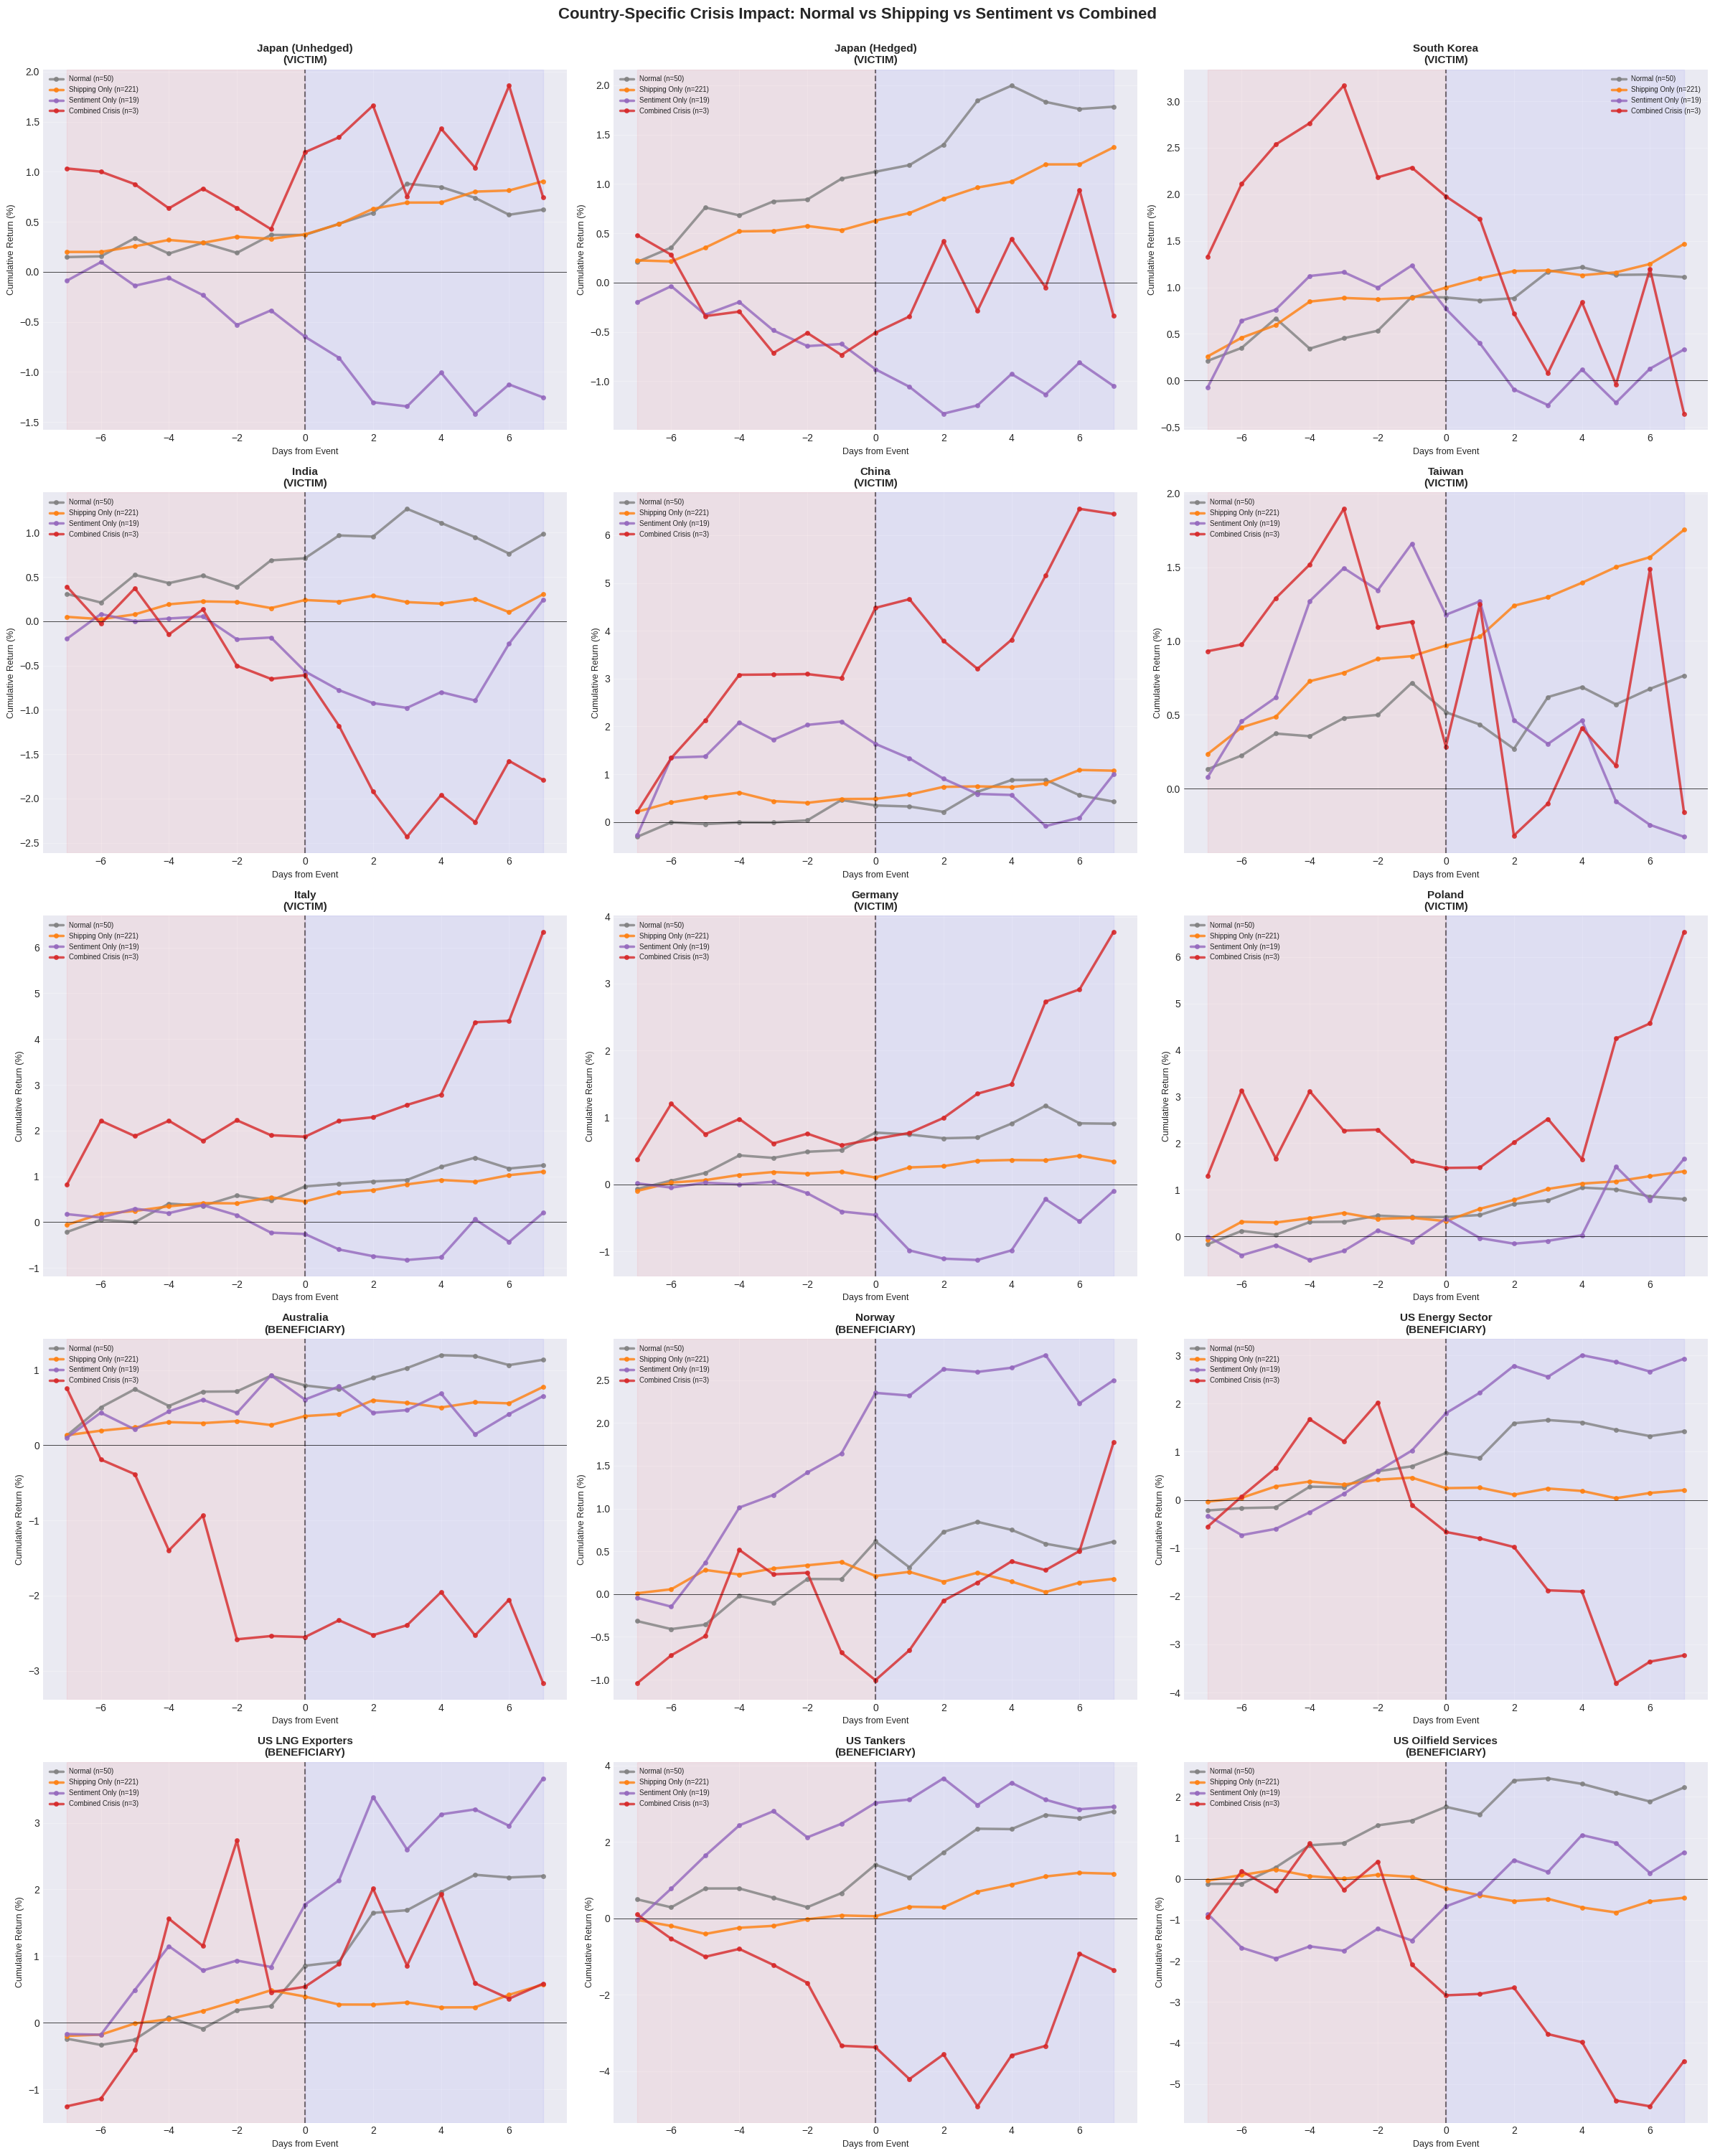

In [42]:
def compare_countries_all_scenarios(analysis_df, victim_groups, beneficiary_groups, window=7, use_corrected=True):
    """
    Run event studies for all countries across FOUR scenarios:
    1. Normal days (baseline)
    2. Shipping Crisis only
    3. Sentiment Crisis only
    4. Combined Crisis (Shipping + Sentiment)
    
    Parameters:
    -----------
    use_corrected : bool, default=True
        If True, uses Lead-2 corrected crisis definitions
        If False, uses original (lagging) crisis definitions
    """
    
    # Choose crisis definitions based on use_corrected parameter
    if use_corrected:
        scenarios = {
            'Normal': 'normal',
            'Shipping Only': 'Shipping_Crisis_Lead2',
            'Sentiment Only': 'Sentiment_Crisis_Lead1',
            'Combined Crisis': 'combined_lead2'
        }
        print("\n" + "="*100)
        print("USING CORRECTED CRISIS DEFINITIONS (Lead-2)")
        print("Crisis flags shifted backward by 2-3 days to capture actual disruption")
        print("="*100)
    else:
        scenarios = {
            'Normal': 'normal',
            'Shipping Only': 'Shipping_Crisis_Original',
            'Sentiment Only': 'Sentiment_Crisis_Original',
            'Combined Crisis': 'combined_original'
        }
        print("\n" + "="*100)
        print("USING ORIGINAL CRISIS DEFINITIONS (Lagging)")
        print("WARNING: These flags are lagging by 2-3 days")
        print("="*100)
    
    all_results = {}
    
    for scenario_name, crisis_type in scenarios.items():
        print("\n" + "="*100)
        print(f"SCENARIO: {scenario_name.upper()}")
        print("="*100)
        
        scenario_results = {}
        
        # Analyze victims
        print(f"\nHigh-Risk Importers:")
        print("-"*100)
        for group_name, etf_list in victim_groups.items():
            result = event_study_country(analysis_df, etf_list, group_name, 
                                        crisis_col=crisis_type, window=window, use_time_adj=True)
            if result:
                scenario_results[group_name] = result
        
        # Analyze beneficiaries
        print(f"\nStrategic Beneficiaries:")
        print("-"*100)
        for group_name, etf_list in beneficiary_groups.items():
            result = event_study_country(analysis_df, etf_list, group_name,
                                        crisis_col=crisis_type, window=window, use_time_adj=True)
            if result:
                scenario_results[group_name] = result
        
        all_results[scenario_name] = scenario_results
    
    return all_results


def event_study_country(df, etf_list, group_name, crisis_col='Shipping_Crisis_Lead2', window=7, use_time_adj=True):
    """
    Event study for a specific country/group of ETFs
    Modified to handle 'normal', 'combined', and corrected crisis types
    """
    suffix = '_TimeAdj' if use_time_adj else ''
    return_cols = [f'{etf}_Return{suffix}' for etf in etf_list if f'{etf}_Return{suffix}' in df.columns]
    
    if len(return_cols) == 0:
        return None
    
    # Handle different crisis types
    if crisis_col == 'normal':
        # Sample random normal days (no crisis)
        # Use original crisis columns to identify normal days
        shipping_col = 'Shipping_Crisis_Original' if 'Shipping_Crisis_Original' in df.columns else 'Shipping_Crisis'
        sentiment_col = 'Sentiment_Crisis_Original' if 'Sentiment_Crisis_Original' in df.columns else 'Sentiment_Crisis'
        
        normal_mask = (df[shipping_col] == 0) & (df[sentiment_col] == 0)
        normal_dates = df[normal_mask].index
        if len(normal_dates) < 20:
            return None
        # Sample 50 random normal days for comparison
        crisis_dates = normal_dates[::len(normal_dates)//min(50, len(normal_dates))][:50]
    
    elif crisis_col == 'combined_lead2':
        # Both shipping AND sentiment crisis (Lead-2 corrected)
        crisis_dates = df[(df['Shipping_Crisis_Lead2'] == True) & (df['Sentiment_Crisis_Lead1'] == True)].index
    
    elif crisis_col == 'combined_original':
        # Both shipping AND sentiment crisis (Original)
        shipping_col = 'Shipping_Crisis_Original' if 'Shipping_Crisis_Original' in df.columns else 'Shipping_Crisis'
        sentiment_col = 'Sentiment_Crisis_Original' if 'Sentiment_Crisis_Original' in df.columns else 'Sentiment_Crisis'
        crisis_dates = df[(df[shipping_col] == 1) & (df[sentiment_col] == 1)].index
    
    else:
        # Regular crisis column (any of the crisis definitions)
        if crisis_col not in df.columns:
            print(f"    WARNING: Column '{crisis_col}' not found in dataframe")
            return None
        
        # Handle boolean or integer columns
        if df[crisis_col].dtype == bool:
            crisis_dates = df[df[crisis_col] == True].index
        else:
            crisis_dates = df[df[crisis_col] == 1].index
    
    if len(crisis_dates) == 0:
        return None
    
    print(f"  {group_name}: {len(crisis_dates)} events")
    
    event_windows = []
    
    for crisis_date in crisis_dates:
        try:
            start_idx = max(0, df.index.get_loc(crisis_date) - window)
            end_idx = min(len(df), df.index.get_loc(crisis_date) + window + 1)
            
            window_data = df.iloc[start_idx:end_idx][return_cols].copy()
            window_data['avg_return'] = window_data.mean(axis=1)
            
            crisis_idx = df.index.get_loc(crisis_date) - start_idx
            window_data['days_from_event'] = range(-crisis_idx, len(window_data) - crisis_idx)
            window_data['event_date'] = crisis_date
            
            event_windows.append(window_data[['avg_return', 'days_from_event', 'event_date']])
        except:
            continue
    
    if len(event_windows) == 0:
        return None
    
    all_events = pd.concat(event_windows)
    avg_returns = all_events.groupby('days_from_event')['avg_return'].mean()
    cum_returns = (1 + avg_returns).cumprod() - 1
    
    return {
        'group': group_name,
        'avg_returns': avg_returns * 100,
        'cum_returns': cum_returns * 100,
        'event_count': len(crisis_dates),
        'n_etfs': len(return_cols)
    }



def print_scenario_comparison(all_results, country_name):
    """
    Print comparison for a specific country across all scenarios
    """
    print(f"\n{'='*100}")
    print(f"{country_name.upper()}")
    print(f"{'='*100}")
    
    for scenario_name, scenario_results in all_results.items():
        if country_name not in scenario_results:
            continue
        
        result = scenario_results[country_name]
        
        print(f"\n{scenario_name} ({result['event_count']} events):")
        print("-"*80)
        
        try:
            pre_avg = result['avg_returns'].loc[-7:-1].mean()
            crisis_day = result['avg_returns'].loc[0]
            post_avg = result['avg_returns'].loc[1:7].mean()
            total = result['cum_returns'].iloc[-1]
            
            print(f"  Pre-Crisis (Days -7 to -1):      {pre_avg:>7.3f}% avg daily")
            print(f"  Crisis Day (Day 0):              {crisis_day:>7.3f}%")
            print(f"  Post-Crisis (Days +1 to +7):     {post_avg:>7.3f}% avg daily")
            print(f"  Total Cumulative (Day -7 to +7): {total:>7.3f}%")
        except:
            print("  Insufficient data")


def plot_scenario_comparison(all_results, victim_groups, beneficiary_groups):
    """
    Plot comparison across all four scenarios for each country
    """
    # Get all countries
    all_countries = list(victim_groups.keys()) + list(beneficiary_groups.keys())
    
    n_countries = len(all_countries)
    n_cols = 3
    n_rows = (n_countries + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    colors = {
        'Normal': '#808080',
        'Shipping Only': '#ff7f0e',
        'Sentiment Only': '#9467bd',
        'Combined Crisis': '#d62728'
    }
    
    for idx, country in enumerate(all_countries):
        ax = axes[idx]
        
        # Plot each scenario
        for scenario_name, scenario_results in all_results.items():
            if country in scenario_results:
                result = scenario_results[country]
                ax.plot(result['cum_returns'].index, result['cum_returns'].values,
                       linewidth=2.5, marker='o', markersize=4, 
                       label=f"{scenario_name} (n={result['event_count']})",
                       color=colors.get(scenario_name, '#000000'),
                       alpha=0.8)
        
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax.axvspan(-7, 0, alpha=0.05, color='red')
        ax.axvspan(0, 7, alpha=0.05, color='blue')
        
        # Determine if victim or beneficiary
        is_victim = country in victim_groups
        category = "VICTIM" if is_victim else "BENEFICIARY"
        
        ax.set_title(f"{country}\n({category})", fontsize=11, fontweight='bold')
        ax.set_xlabel('Days from Event', fontsize=9)
        ax.set_ylabel('Cumulative Return (%)', fontsize=9)
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(all_countries), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Country-Specific Crisis Impact: Normal vs Shipping vs Sentiment vs Combined', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


def create_summary_table(all_results, victim_groups, beneficiary_groups):
    """
    Create summary table comparing all four scenarios
    """
    print("\n" + "="*120)
    print("SUMMARY TABLE: TOTAL CUMULATIVE RETURNS (Day -7 to +7)")
    print("="*120)
    
    all_countries = list(victim_groups.keys()) + list(beneficiary_groups.keys())
    
    # Header
    print(f"\n{'Country':<25} | {'Normal':>12} | {'Shipping':>12} | {'Sentiment':>12} | {'Combined':>12} | {'Category':<12}")
    print("-"*120)
    
    for country in all_countries:
        is_victim = country in victim_groups
        category = "VICTIM" if is_victim else "BENEFICIARY"
        
        row = f"{country:<25} |"
        
        for scenario_name in ['Normal', 'Shipping Only', 'Sentiment Only', 'Combined Crisis']:
            if scenario_name in all_results and country in all_results[scenario_name]:
                result = all_results[scenario_name][country]
                try:
                    total = result['cum_returns'].iloc[-1]
                    row += f" {total:>11.2f}% |"
                except:
                    row += f" {'N/A':>11} |"
            else:
                row += f" {'N/A':>11} |"
        
        row += f" {category:<12}"
        print(row)


def create_impact_comparison(all_results, victim_groups, beneficiary_groups):
    """
    Show which crisis type has the biggest impact for each country
    """
    print("\n" + "="*100)
    print("CRISIS TYPE IMPACT RANKING (Most Negative to Most Positive)")
    print("="*100)
    
    all_countries = list(victim_groups.keys()) + list(beneficiary_groups.keys())
    
    for country in all_countries:
        is_victim = country in victim_groups
        category = "VICTIM" if is_victim else "BENEFICIARY"
        
        print(f"\n{country} ({category}):")
        print("-"*100)
        
        impacts = []
        for scenario_name in ['Normal', 'Shipping Only', 'Sentiment Only', 'Combined Crisis']:
            if scenario_name in all_results and country in all_results[scenario_name]:
                result = all_results[scenario_name][country]
                try:
                    total = result['cum_returns'].iloc[-1]
                    impacts.append((scenario_name, total, result['event_count']))
                except:
                    pass
        
        # Sort by impact
        impacts.sort(key=lambda x: x[1])
        
        for rank, (scenario, impact, count) in enumerate(impacts, 1):
            status = "⚠️" if impact < -2 else "✅" if impact > 2 else "→"
            print(f"  {rank}. {scenario:<20} | {impact:>7.2f}% | (n={count:>3}) {status}")


# Run the enhanced analysis
print("="*100)
print("RUNNING COMPREHENSIVE 4-SCENARIO ANALYSIS")
print("="*100)

all_scenario_results = compare_countries_all_scenarios(analysis_df, victim_groups, beneficiary_groups, window=7)

# Print detailed comparison for each country
print("\n" + "="*100)
print("DETAILED COUNTRY COMPARISONS")
print("="*100)

for country in list(victim_groups.keys()) + list(beneficiary_groups.keys()):
    print_scenario_comparison(all_scenario_results, country)

# Create summary table
create_summary_table(all_scenario_results, victim_groups, beneficiary_groups)

# Show impact ranking
create_impact_comparison(all_scenario_results, victim_groups, beneficiary_groups)

# Visualize
plot_scenario_comparison(all_scenario_results, victim_groups, beneficiary_groups)


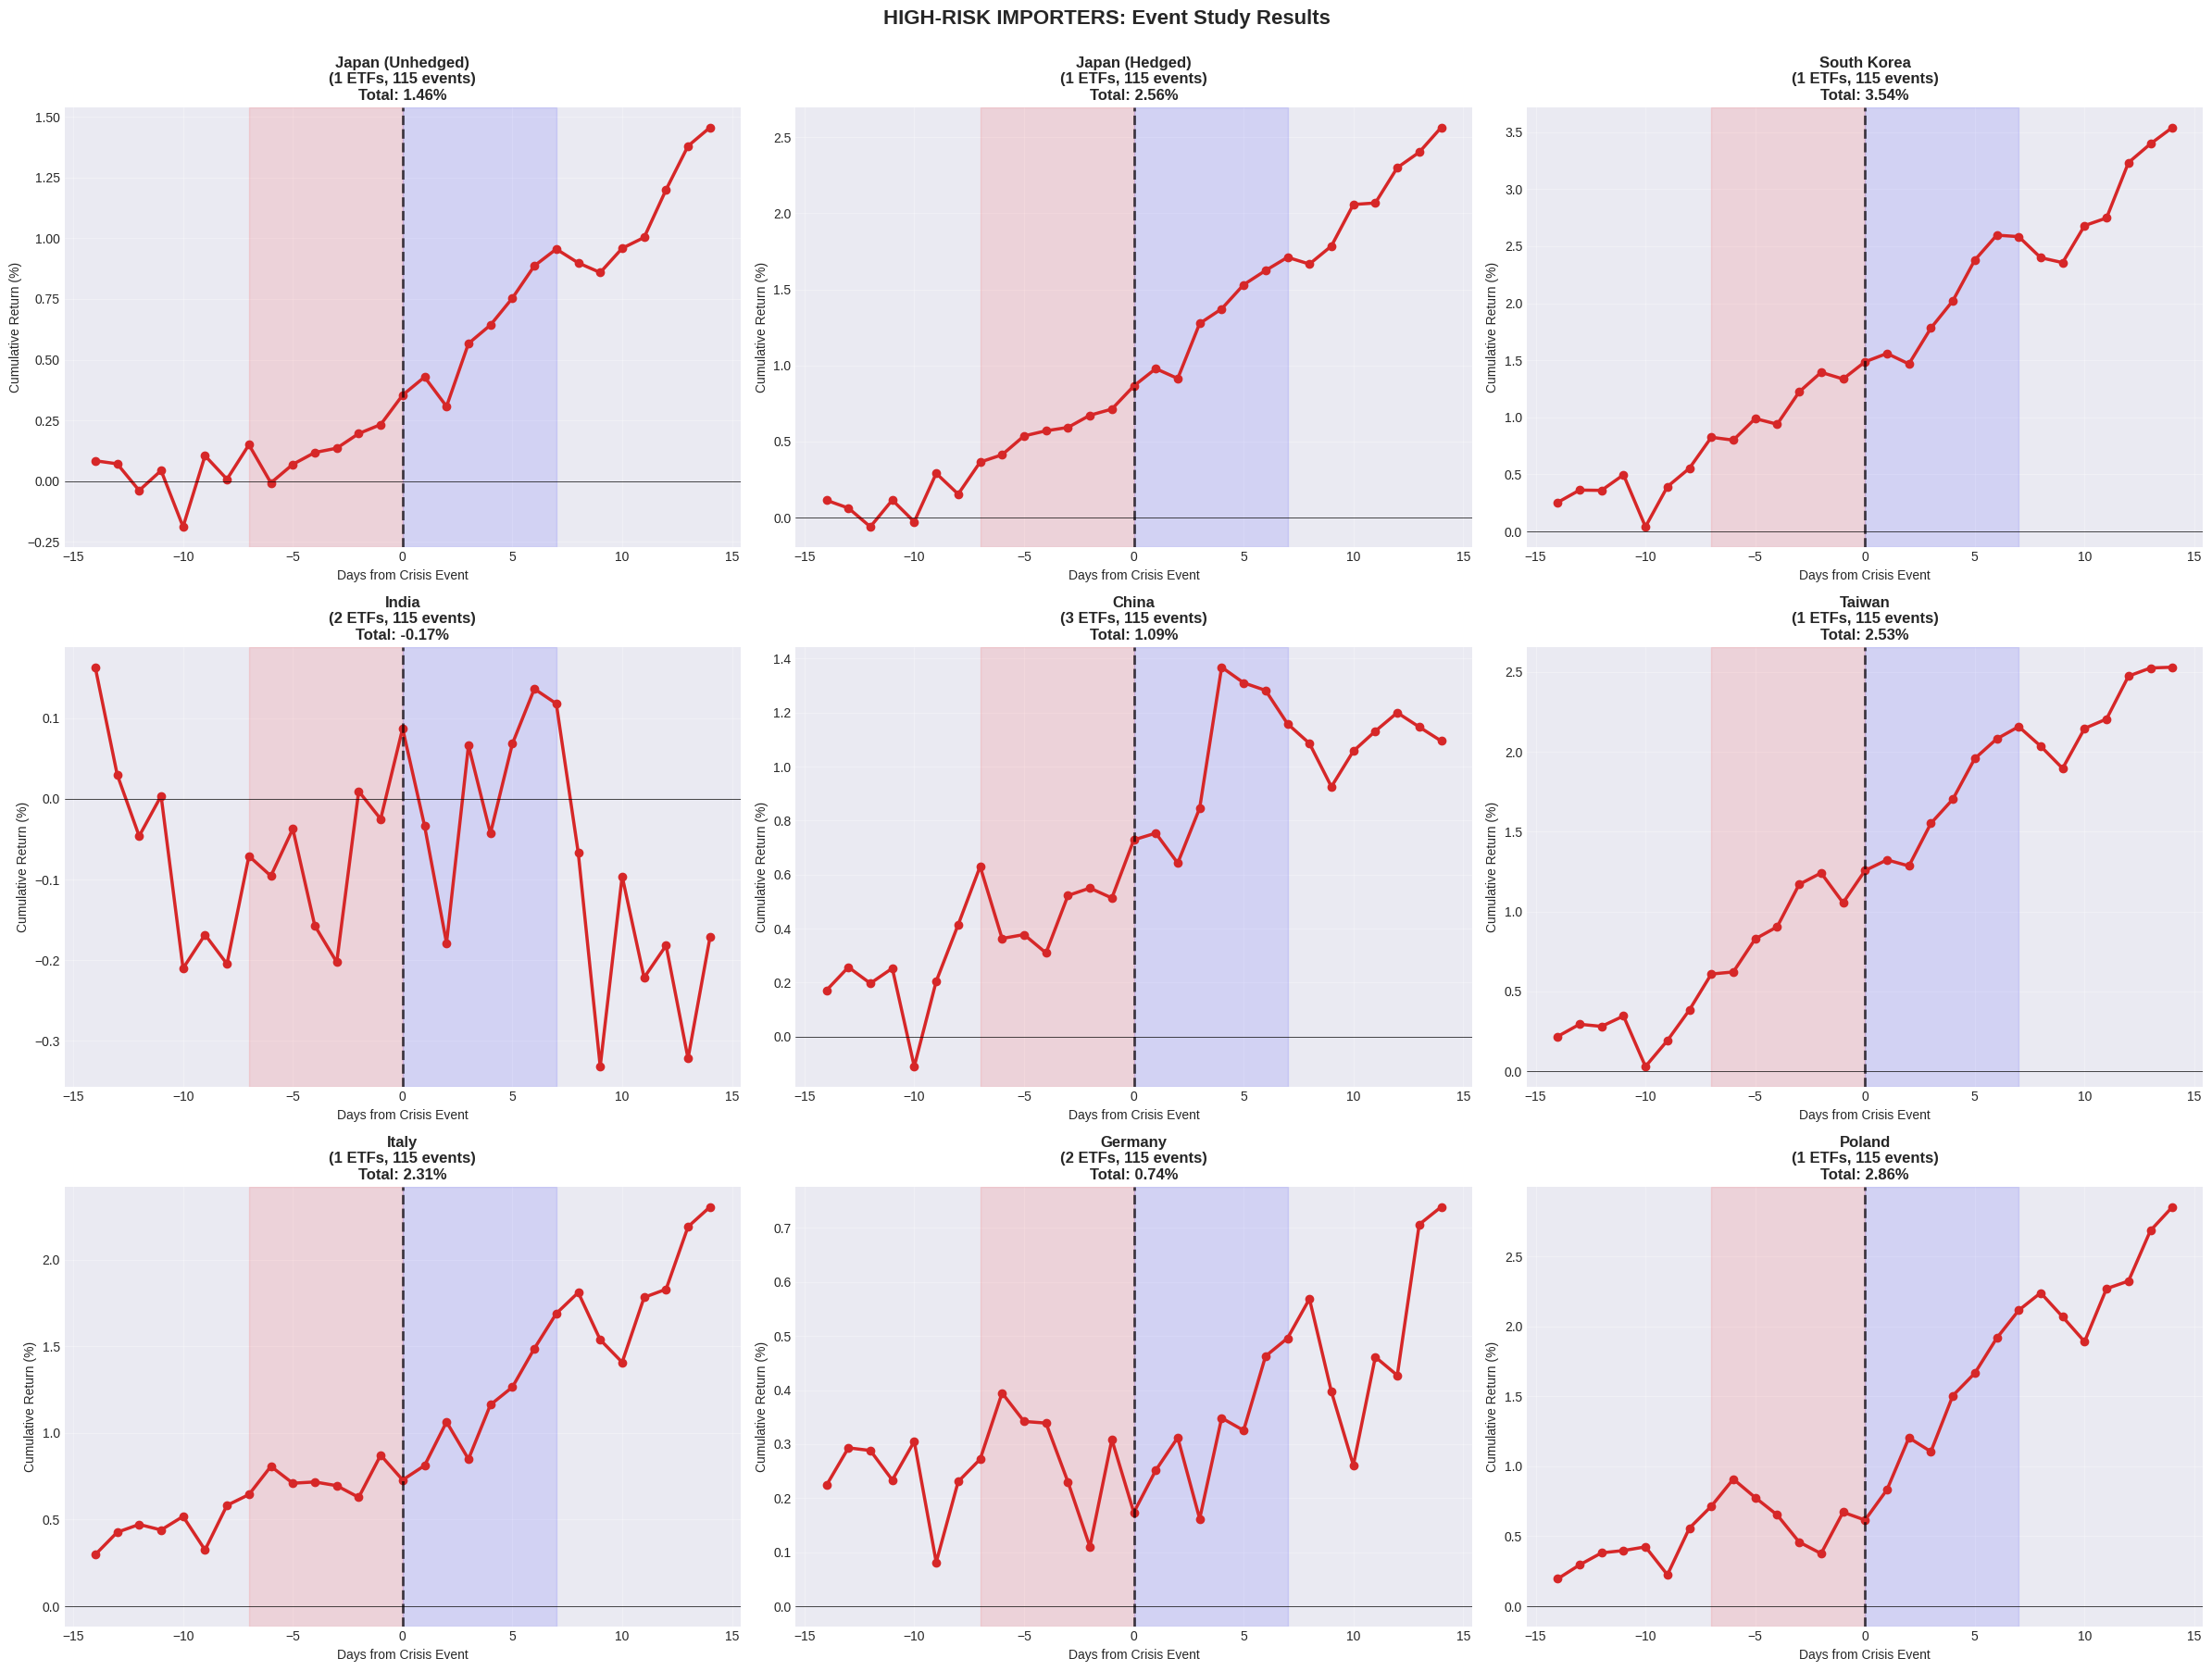

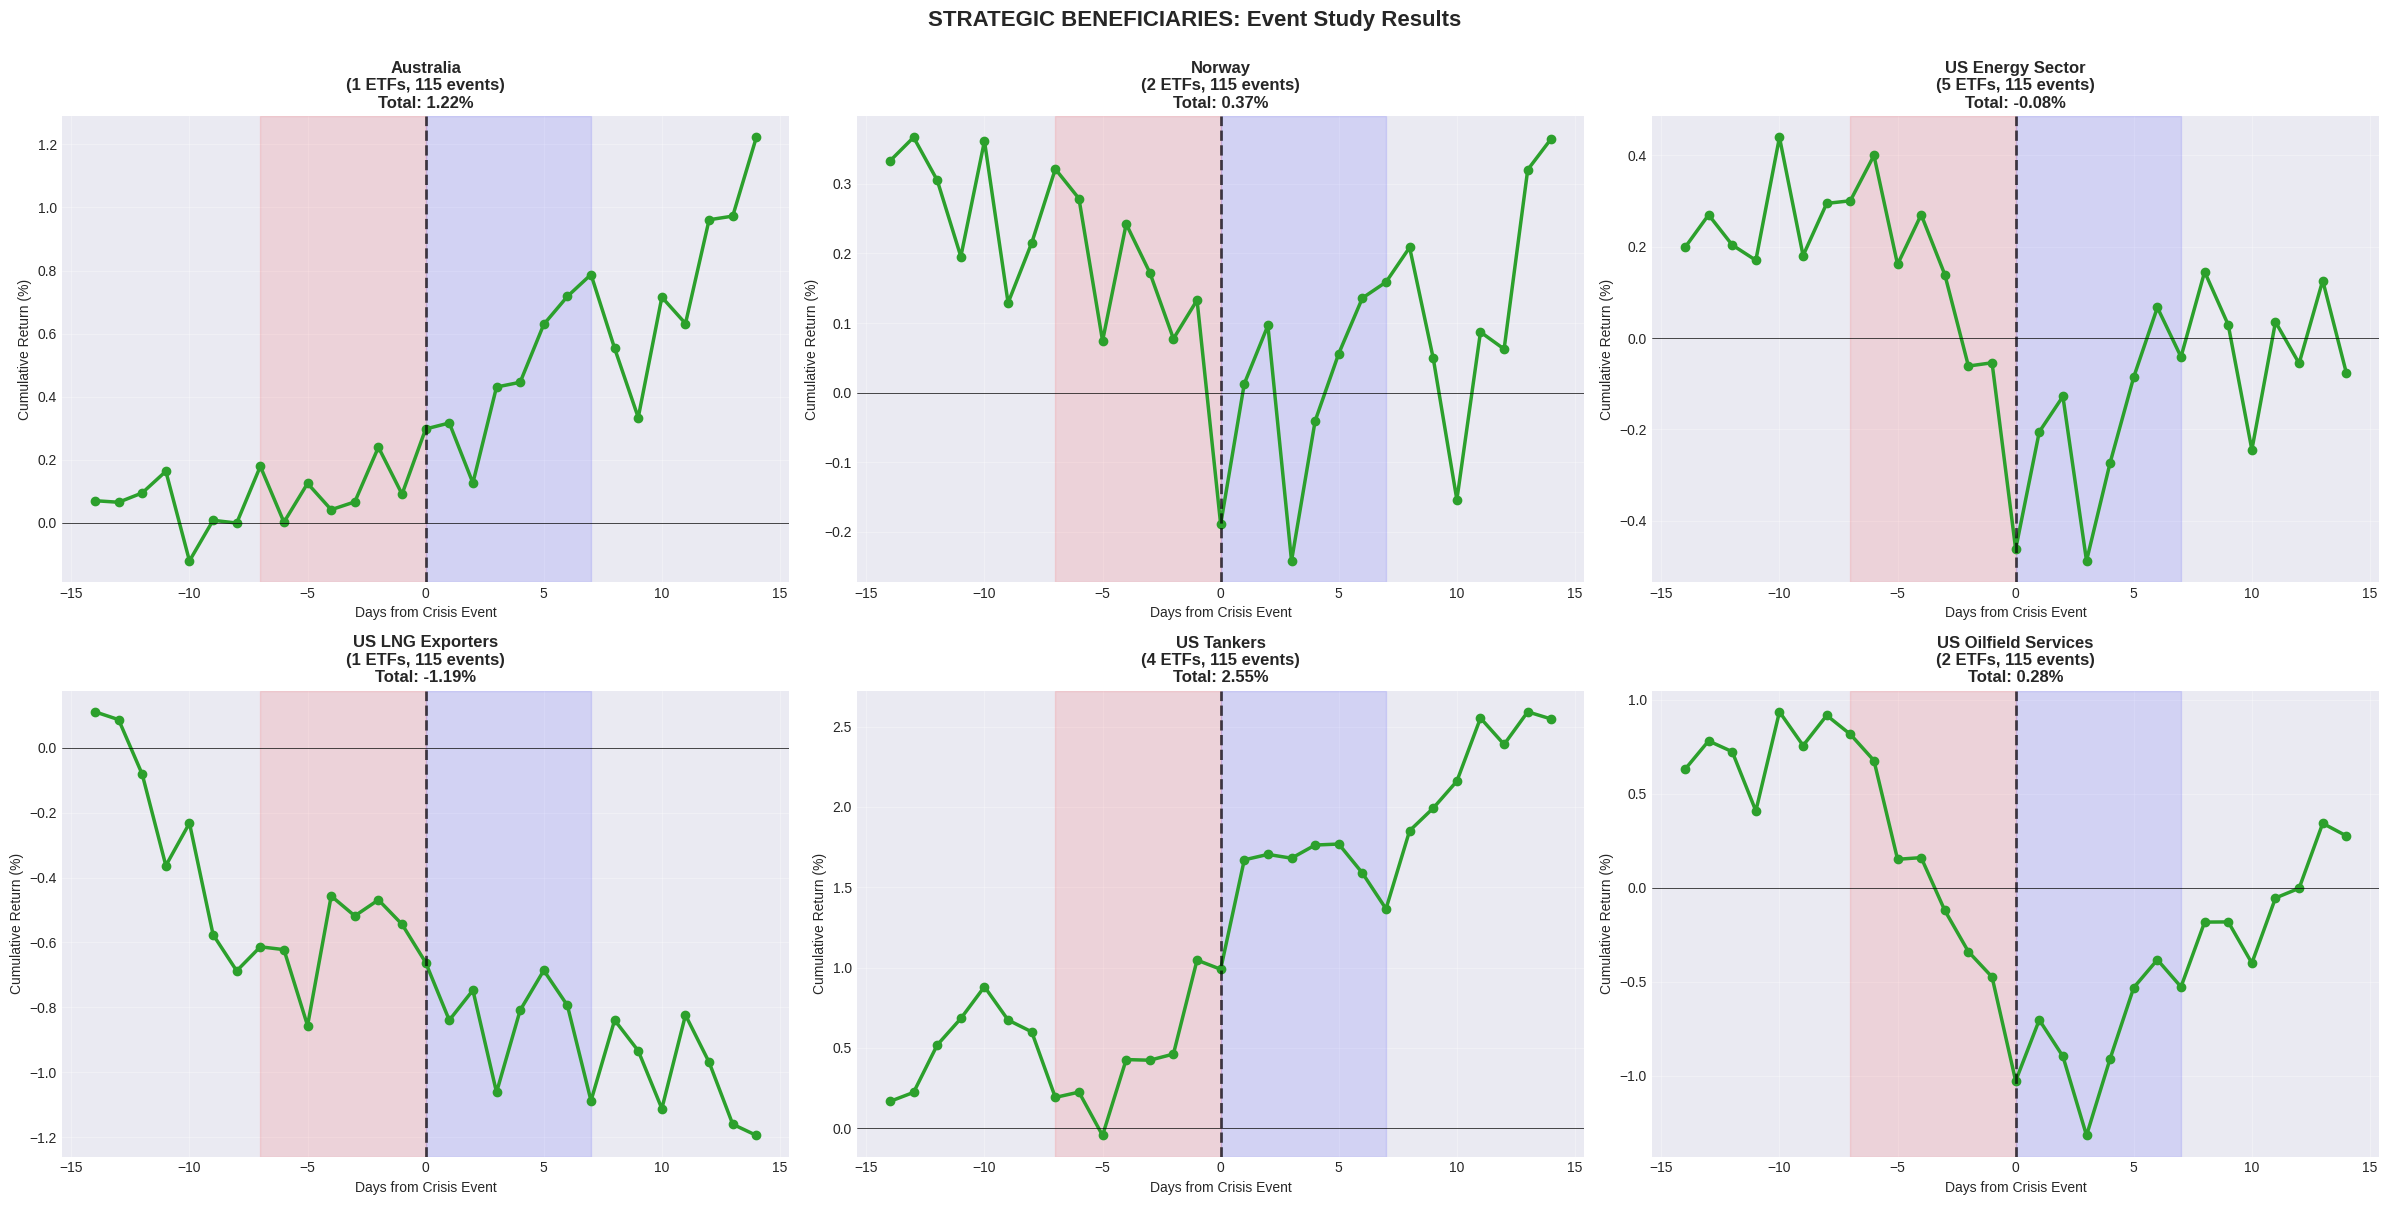

COMPARATIVE RANKING

Countries ranked by total crisis impact (Day -7 to +7):
----------------------------------------------------------------------------------------------------
 1. South Korea               |    3.54% | ✅ WINNER
 2. Poland                    |    2.86% | ✅ WINNER
 3. Japan (Hedged)            |    2.56% | ✅ WINNER
 4. US Tankers                |    2.55% | ✅ WINNER
 5. Taiwan                    |    2.53% | ✅ WINNER
 6. Italy                     |    2.31% | ✅ WINNER
 7. Japan (Unhedged)          |    1.46% | → NEUTRAL
 8. Australia                 |    1.22% | → NEUTRAL
 9. China                     |    1.09% | → NEUTRAL
10. Germany                   |    0.74% | → NEUTRAL
11. Norway                    |    0.37% | → NEUTRAL
12. US Oilfield Services      |    0.28% | → NEUTRAL
13. US Energy Sector          |   -0.08% | → NEUTRAL
14. India                     |   -0.17% | → NEUTRAL
15. US LNG Exporters          |   -1.19% | → NEUTRAL


In [43]:
plot_country_event_studies(country_results, victim_groups, beneficiary_groups)
print("COMPARATIVE RANKING")
# Sort by total impact
sorted_results = sorted(country_results.items(), 
                       key=lambda x: x[1]['cum_returns'].iloc[-1], 
                       reverse=True)

print("\nCountries ranked by total crisis impact (Day -7 to +7):")
print("-"*100)
for rank, (country, result) in enumerate(sorted_results, 1):
    total = result['cum_returns'].iloc[-1]
    status = "✅ WINNER" if total > 2 else "⚠️ LOSER" if total < -2 else "→ NEUTRAL"
    print(f"{rank:>2}. {country:<25} | {total:>7.2f}% | {status}")

In [ ]:
def analyze_country_group(df, etf_list, group_name, crisis_col='Shipping_Crisis', use_time_adj=True):
    """
    Analyze a group of ETFs during crisis vs normal periods
    """
    suffix = '_TimeAdj' if use_time_adj else ''
    return_cols = [f'{etf}_Return{suffix}' for etf in etf_list if f'{etf}_Return{suffix}' in df.columns]
    
    if len(return_cols) == 0:
        return None
    
    crisis_mask = df[crisis_col] == 1
    normal_mask = df[crisis_col] == 0
    
    crisis_returns = df[crisis_mask][return_cols].mean(axis=1).mean() * 100
    normal_returns = df[normal_mask][return_cols].mean(axis=1).mean() * 100
    
    crisis_vol = df[crisis_mask][return_cols].mean(axis=1).std() * 100 * np.sqrt(252)
    normal_vol = df[normal_mask][return_cols].mean(axis=1).std() * 100 * np.sqrt(252)
    
    return {
        'group': group_name,
        'n_etfs': len(return_cols),
        'crisis_return': crisis_returns,
        'normal_return': normal_returns,
        'difference': crisis_returns - normal_returns,
        'crisis_vol': crisis_vol,
        'normal_vol': normal_vol,
        'crisis_days': crisis_mask.sum(),
        'normal_days': normal_mask.sum()
    }

# Define country groups
victim_groups = {
    'Japan (Unhedged)': ['ASIA_EWJ'],
    'Japan (Hedged)': ['ASIA_DXJ'],
    'South Korea': ['ASIA_EWY'],
    'India': ['ASIA_INDA', 'ASIA_INDY'],
    'China': ['ASIA_FXI', 'ASIA_MCHI', 'ASIA_ASHR'],
    'Taiwan': ['ASIA_EWT'],
    'Italy': ['EU_EWI'],
    'Germany': ['EU_EWG', 'EU_DXGE'],
    'Poland': ['EU_EPOL'],
}

beneficiary_groups = {
    'Australia': ['ASIA_EWA'],
    'Norway': ['EU_NORW', 'EU_EQNR'],
    'US Energy Sector': ['US_XLE', 'US_XOM', 'US_CVX', 'US_COP', 'US_EOG'],
    'US LNG Exporters': ['US_LNG'],
    'US Tankers': ['US_STNG', 'US_DHT', 'US_FRO', 'US_TNK'],
    'US Oilfield Services': ['US_HAL', 'US_SLB'],
}

print("Country groups defined. Ready for analysis!")


In [ ]:
print("="*100)
print("COUNTRY-SPECIFIC CRISIS IMPACT ANALYSIS (Time-Adjusted)")
print("="*100)

# Analyze victims
print("\n" + "="*100)
print("HIGH-RISK IMPORTERS (Expected: NEGATIVE impact)")
print("="*100)

victim_results = []
for group_name, etf_list in victim_groups.items():
    result = analyze_country_group(analysis_df, etf_list, group_name, use_time_adj=True)
    if result:
        victim_results.append(result)
        status = "✓ As Expected" if result['difference'] < 0 else "✗ UNEXPECTED"
        print(f"\n{group_name}:")
        print(f"  Crisis Return: {result['crisis_return']:>7.3f}%")
        print(f"  Normal Return: {result['normal_return']:>7.3f}%")
        print(f"  Difference:    {result['difference']:>7.3f}% {status}")

# Analyze beneficiaries
print("\n" + "="*100)
print("STRATEGIC BENEFICIARIES (Expected: POSITIVE impact)")
print("="*100)

beneficiary_results = []
for group_name, etf_list in beneficiary_groups.items():
    result = analyze_country_group(analysis_df, etf_list, group_name, use_time_adj=True)
    if result:
        beneficiary_results.append(result)
        status = "✓ As Expected" if result['difference'] > 0 else "✗ UNEXPECTED"
        print(f"\n{group_name}:")
        print(f"  Crisis Return: {result['crisis_return']:>7.3f}%")
        print(f"  Normal Return: {result['normal_return']:>7.3f}%")
        print(f"  Difference:    {result['difference']:>7.3f}% {status}")

victim_df = pd.DataFrame(victim_results)
beneficiary_df = pd.DataFrame(beneficiary_results)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Plot 1: Victims - Crisis vs Normal
ax = axes[0, 0]
x = np.arange(len(victim_df))
width = 0.35
ax.bar(x - width/2, victim_df['crisis_return'], width, label='Crisis', color='#d62728', alpha=0.8)
ax.bar(x + width/2, victim_df['normal_return'], width, label='Normal', color='#2ca02c', alpha=0.8)
ax.set_xlabel('Country/Region')
ax.set_ylabel('Average Daily Return (%)')
ax.set_title('High-Risk Importers: Crisis vs Normal Returns', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(victim_df['group'], rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Beneficiaries - Crisis vs Normal
ax = axes[0, 1]
x = np.arange(len(beneficiary_df))
ax.bar(x - width/2, beneficiary_df['crisis_return'], width, label='Crisis', color='#d62728', alpha=0.8)
ax.bar(x + width/2, beneficiary_df['normal_return'], width, label='Normal', color='#2ca02c', alpha=0.8)
ax.set_xlabel('Country/Sector')
ax.set_ylabel('Average Daily Return (%)')
ax.set_title('Strategic Beneficiaries: Crisis vs Normal Returns', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(beneficiary_df['group'], rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Impact Difference
ax = axes[1, 0]
all_results = pd.concat([victim_df, beneficiary_df]).sort_values('difference')
colors = ['#d62728' if x < 0 else '#2ca02c' for x in all_results['difference']]
ax.barh(all_results['group'], all_results['difference'], color=colors, alpha=0.8)
ax.set_xlabel('Return Difference: Crisis - Normal (%)')
ax.set_title('Crisis Impact by Country/Sector (Sorted)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

# Plot 4: Volatility Comparison
ax = axes[1, 1]
ax.scatter(victim_df['normal_vol'], victim_df['crisis_vol'], s=100, alpha=0.6, label='Victims', color='#d62728')
ax.scatter(beneficiary_df['normal_vol'], beneficiary_df['crisis_vol'], s=100, alpha=0.6, label='Beneficiaries', color='#2ca02c')
for idx, row in victim_df.iterrows():
    ax.annotate(row['group'], (row['normal_vol'], row['crisis_vol']), fontsize=8, alpha=0.7)
for idx, row in beneficiary_df.iterrows():
    ax.annotate(row['group'], (row['normal_vol'], row['crisis_vol']), fontsize=8, alpha=0.7)
ax.plot([0, 50], [0, 50], 'k--', alpha=0.3, label='Equal Volatility')
ax.set_xlabel('Normal Period Volatility (% annualized)')
ax.set_ylabel('Crisis Period Volatility (% annualized)')
ax.set_title('Volatility: Crisis vs Normal Periods', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
print("KEY FINDINGS SUMMARY")

print("\n1. BIGGEST WINNERS DURING CRISES:")
print("-" * 100)
all_results_sorted = pd.concat([victim_df, beneficiary_df]).sort_values('difference', ascending=False)
for _, row in all_results_sorted.head(5).iterrows():
    print(f"  {row['group']:<25} | +{row['difference']:>6.3f}% | Crisis: {row['crisis_return']:>6.3f}% | Normal: {row['normal_return']:>6.3f}%")

print("\n2. BIGGEST LOSERS DURING CRISES:")
print("-" * 100)
for _, row in all_results_sorted.tail(5).iterrows():
    print(f"  {row['group']:<25} | {row['difference']:>7.3f}% | Crisis: {row['crisis_return']:>6.3f}% | Normal: {row['normal_return']:>6.3f}%")

print("\n3. VALIDATION CHECK:")
print("-" * 100)
victims_correct = (victim_df['difference'] < 0).sum()
beneficiaries_correct = (beneficiary_df['difference'] > 0).sum()
print(f"  Victims showing expected NEGATIVE impact:      {victims_correct}/{len(victim_df)} ({victims_correct/len(victim_df)*100:.0f}%)")
print(f"  Beneficiaries showing expected POSITIVE impact: {beneficiaries_correct}/{len(beneficiary_df)} ({beneficiaries_correct/len(beneficiary_df)*100:.0f}%)")

print("\n" + "="*100)
print("ANALYSIS COMPLETE!")
print("="*100)
